In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import LabelEncoder
import kagglehub

In [2]:
path = kagglehub.dataset_download("jp797498e/twitter-entity-sentiment-analysis")

Using Colab cache for faster access to the 'twitter-entity-sentiment-analysis' dataset.


In [3]:
train = pd.read_csv(path + '/twitter_training.csv')
test = pd.read_csv(path + '//twitter_validation.csv')

In [4]:
train.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [5]:
train.columns

Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')

In [6]:
train.rename(columns={'2401':'id',  'Borderlands': 'channel', 'Positive':'sentiment', 'im getting on borderlands and i will murder you all ,':'text'}, inplace=True)

In [7]:
test.head()

,3364,Facebook,Irrelevant,"I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣"
0,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
1,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
2,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
3,4433,Google,Neutral,Now the President is slapping Americans in the...
4,6273,FIFA,Negative,Hi @EAHelp I’ve had Madeleine McCann in my cel...


In [8]:
test.columns

Index(['3364', 'Facebook', 'Irrelevant',
       'I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣'],
      dtype='object')

In [9]:
test.rename(columns={'3364':'id',  'Facebook': 'channel', 'Irrelevant':'sentiment', 'I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣':'text'}, inplace=True)

In [10]:
train.sentiment.value_counts()

,count
sentiment,
Negative,22542
Positive,20831
Neutral,18318
Irrelevant,12990


In [14]:
train.isna().sum()

,0
id,0
channel,0
sentiment,0
text,0


In [12]:
test.isna().sum()

,0
id,0
channel,0
sentiment,0
text,0


In [13]:
train.dropna(inplace=True)

In [15]:
train.duplicated().sum()

np.int64(2340)

In [16]:
test.duplicated().sum()

np.int64(0)

In [17]:
train = train.drop_duplicates(keep='first')

In [18]:
X_train, y_train = (train.text, train.sentiment)
X_test, y_test = (test.text, test.sentiment)

In [19]:
import re
def clean(data):
  ## Removing URLs with regex
  url_pattern = re.compile(r'https?://\S+|www\.\S+')
  data = url_pattern.sub(r'', data)

  # Remove emails
  data = re.sub('\S*@\S*s?', '', data)

  # Remove new line characters
  data = re.sub('\s+', ' ', data)

  # Remove single quotes
  data = re.sub("\'", "", data)

  return data


<>:8: SyntaxWarning: invalid escape sequence '\S'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\S'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_15496/3488128098.py:8: SyntaxWarning: invalid escape sequence '\S'
  data = re.sub('\S*@\S*s?', '', data)
/tmp/ipykernel_15496/3488128098.py:11: SyntaxWarning: invalid escape sequence '\s'
  data = re.sub('\s+', ' ', data)


In [20]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
def sent_to_words(sentences):
  return [[word for word in word_tokenize(str(sentence).lower()) if word.isalpha()] for sentence in sentences]


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [21]:
from nltk.tokenize.treebank import TreebankWordDetokenizer
def detokenize(text):
  return TreebankWordDetokenizer().detokenize(text)

In [22]:
X_train.values.tolist()

['I am coming to the borders and I will kill you all,',
 'im getting on borderlands and i will kill you all,',
 'im coming on borderlands and i will murder you all,',
 'im getting on borderlands 2 and i will murder you me all,',
 'im getting into borderlands and i can murder you all,',
 "So I spent a few hours making something for fun. . . If you don't know I am a HUGE @Borderlands fan and Maya is one of my favorite characters. So I decided to make myself a wallpaper for my PC. . Here is the original image versus the creation I made :) Enjoy! pic.twitter.com/mLsI5wf9Jg",
 "So I spent a couple of hours doing something for fun... If you don't know that I'm a huge @ Borderlands fan and Maya is one of my favorite characters, I decided to make a wallpaper for my PC.. Here's the original picture compared to the creation I made:) Have fun! pic.twitter.com / mLsI5wf9Jg",
 "So I spent a few hours doing something for fun... If you don't know I'm a HUGE @ Borderlands fan and Maya is one of my fav

In [23]:
temp = []
data_to_list = X_train.values.tolist()
for i in range(len(data_to_list)):
  temp.append(clean(data_to_list[i]))

data_words = list(sent_to_words(temp))
X_train = []
for i in range(len(data_words)):
  X_train.append(detokenize(data_words[i]))

In [24]:
temp = []
data_to_list = X_test.values.tolist()
for i in range(len(data_to_list)):
  temp.append(clean(data_to_list[i]))

data_words = list(sent_to_words(temp))
X_test = []
for i in range(len(data_words)):
  X_test.append(detokenize(data_words[i]))

In [25]:
X_train

['i am coming to the borders and i will kill you all',
 'im getting on borderlands and i will kill you all',
 'im coming on borderlands and i will murder you all',
 'im getting on borderlands and i will murder you me all',
 'im getting into borderlands and i can murder you all',
 'so i spent a few hours making something for fun if you dont know i am a huge fan and maya is one of my favorite characters so i decided to make myself a wallpaper for my pc here is the original image versus the creation i made enjoy',
 'so i spent a couple of hours doing something for fun if you dont know that im a huge borderlands fan and maya is one of my favorite characters i decided to make a wallpaper for my pc heres the original picture compared to the creation i made have fun',
 'so i spent a few hours doing something for fun if you dont know im a huge borderlands fan and maya is one of my favorite characters',
 'so i spent a few hours making something for fun if you dont know i am a huge rhandlerr fan

In [26]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

In [27]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 5000
max_len = 200

tokenizer = Tokenizer(num_words = max_words)
tokenizer.fit_on_texts(X_train)

sequnces = tokenizer.texts_to_sequences(X_train)
X_train = pad_sequences(sequnces, maxlen=max_len)

sequnces = tokenizer.texts_to_sequences(X_test)
X_test = pad_sequences(sequnces, maxlen=max_len)

In [28]:
X_train[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

In [29]:
model = Sequential()
model.add(layers.Embedding(max_words + 1, 50))
model.add(layers.Bidirectional(layers.LSTM(50, return_sequences=True)))
model.add(layers.Bidirectional(layers.LSTM(50)))
model.add(layers.Dense(4, activation='softmax'))

In [30]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [42]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 50)        │       250,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200, 100)       │        40,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 100)            │        60,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           404 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,053,764 (4.02 MB)

 Trainable params: 351,254 (1.34 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 702,510 (2.68 MB)

In [46]:
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
2240/2240 ━━━━━━━━━━━━━━━━━━━━ 944s 421ms/step - accuracy: 0.6257 - loss: 0.9240 - val_accuracy: 0.8258 - val_loss: 0.5231
Epoch 2/10
2240/2240 ━━━━━━━━━━━━━━━━━━━━ 943s 421ms/step - accuracy: 0.7636 - loss: 0.6246 - val_accuracy: 0.8779 - val_loss: 0.3758
Epoch 3/10
2240/2240 ━━━━━━━━━━━━━━━━━━━━ 975s 418ms/step - accuracy: 0.8138 - loss: 0.4946 - val_accuracy: 0.9049 - val_loss: 0.3266
Epoch 4/10
2240/2240 ━━━━━━━━━━━━━━━━━━━━ 958s 407ms/step - accuracy: 0.8462 - loss: 0.4105 - val_accuracy: 0.9099 - val_loss: 0.3096
Epoch 5/10
2240/2240 ━━━━━━━━━━━━━━━━━━━━ 925s 413ms/step - accuracy: 0.8697 - loss: 0.3431 - val_accuracy: 0.9089 - val_loss: 0.3094
Epoch 6/10
2240/2240 ━━━━━━━━━━━━━━━━━━━━ 948s 398ms/step - accuracy: 0.8883 - loss: 0.2918 - val_accuracy: 0.9199 - val_loss: 0.2905
Epoch 7/10
2240/2240 ━━━━━━━━━━━━━━━━━━━━ 1000s 433ms/step - accuracy: 0.9030 - loss: 0.2530 - val_accuracy: 0.9299 - val_loss: 0.3166
Epoch 8/10
2240/2240 ━━━━━━━━━━━━━━━━━━━━ 943s 421ms/step - a

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step


<Axes: >

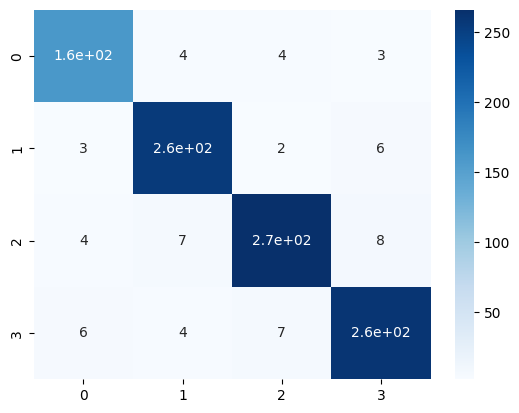

In [47]:
preds = model.predict(X_test)
classes = preds.argmax(axis=1)
sns.heatmap(confusion_matrix(y_test, classes), annot=True, cmap='Blues')

In [48]:
print(classification_report(y_test, classes))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       171
           1       0.94      0.96      0.95       266
           2       0.95      0.93      0.94       285
           3       0.94      0.94      0.94       277

    accuracy                           0.94       999
   macro avg       0.94      0.94      0.94       999
weighted avg       0.94      0.94      0.94       999



In [49]:
print("Label mapping: ", dict(zip(encoder.classes_, range(len(encoder.classes_)))))

Label mapping:  {'Irrelevant': 0, 'Negative': 1, 'Neutral': 2, 'Positive': 3}


In [61]:
sentiment = ['Irrelevant', 'Negative', 'Neutral', 'Positive']
sequence = tokenizer.texts_to_sequences(['I hate this movie.'])
test = pad_sequences(sequence, maxlen=max_len)
sentiment[np.around(model.predict(test), decimals=2).argmax(axis=1)[0]]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


'Negative'

In [62]:
np.around(model.predict(test), decimals=2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


array([[0.  , 0.98, 0.01, 0.01]], dtype=float32)

In [54]:
model_conv = Sequential()
model_conv.add(layers.Embedding(max_words+1, 50))
model_conv.add(layers.Conv1D(30, 6, activation='relu'))
model_conv.add(layers.MaxPooling1D(5))
model_conv.add(layers.Dropout(0.5))
model_conv.add(layers.Conv1D(30, 6, activation='relu'))
model_conv.add(layers.GlobalMaxPooling1D())
model_conv.add(layers.Dropout(0.5))
model_conv.add(layers.Dense(4, activation='softmax'))

model_conv.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['acc'])
history = model_conv.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Epoch 1/10
2240/2240 ━━━━━━━━━━━━━━━━━━━━ 72s 31ms/step - acc: 0.4776 - loss: 1.1819 - val_acc: 0.6677 - val_loss: 0.8923
Epoch 2/10
2240/2240 ━━━━━━━━━━━━━━━━━━━━ 66s 30ms/step - acc: 0.6262 - loss: 0.9425 - val_acc: 0.7748 - val_loss: 0.6772
Epoch 3/10
2240/2240 ━━━━━━━━━━━━━━━━━━━━ 66s 30ms/step - acc: 0.6865 - loss: 0.8082 - val_acc: 0.8348 - val_loss: 0.5361
Epoch 4/10
2240/2240 ━━━━━━━━━━━━━━━━━━━━ 79s 28ms/step - acc: 0.7256 - loss: 0.7259 - val_acc: 0.8599 - val_loss: 0.4801
Epoch 5/10
2240/2240 ━━━━━━━━━━━━━━━━━━━━ 72s 32ms/step - acc: 0.7469 - loss: 0.6672 - val_acc: 0.8779 - val_loss: 0.4365
Epoch 6/10
2240/2240 ━━━━━━━━━━━━━━━━━━━━ 71s 31ms/step - acc: 0.7625 - loss: 0.6220 - val_acc: 0.8819 - val_loss: 0.4024
Epoch 7/10
2240/2240 ━━━━━━━━━━━━━━━━━━━━ 72s 32ms/step - acc: 0.7780 - loss: 0.5822 - val_acc: 0.9019 - val_loss: 0.3854
Epoch 8/10
2240/2240 ━━━━━━━━━━━━━━━━━━━━ 74s 33ms/step - acc: 0.7891 - loss: 0.5564 - val_acc: 0.8979 - val_loss: 0.3949
Epoch 9/10
2240/2240 ━━━

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


<Axes: >

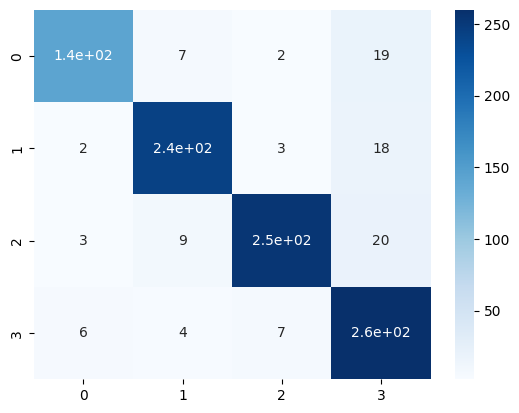

In [63]:
preds = model_conv.predict(X_test)
classes = preds.argmax(axis=1)
sns.heatmap(confusion_matrix(y_test, classes), annot=True, cmap='Blues')

In [64]:
print(classification_report(y_test, classes))

              precision    recall  f1-score   support

           0       0.93      0.84      0.88       171
           1       0.92      0.91      0.92       266
           2       0.95      0.89      0.92       285
           3       0.82      0.94      0.88       277

    accuracy                           0.90       999
   macro avg       0.91      0.89      0.90       999
weighted avg       0.90      0.90      0.90       999



In [65]:
sentiment = ['Irrelevant', 'Negative', 'Neutral', 'Positive']
sequence = tokenizer.texts_to_sequences(["I hate the acting in this movie"])
test = pad_sequences(sequence, maxlen=max_len)
sentiment[np.around(model_conv.predict(test), decimals=0).argmax(axis=1)[0]]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


'Negative'

In [66]:
np.around(model_conv.predict(test), decimals=2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


array([[0.21, 0.58, 0.16, 0.06]], dtype=float32)